# First-layer Fiedler recovery under sub-sampling

Similarity-matrix analogue of the Griffing experiment
(`griffing_distance_partition.ipynb`):

1. Generate a tree + sequences → JC similarity matrix $S \in \mathbb R^{m\times m}$.
2. Reference partition vector: Fiedler of $L(S) = D_S - S$ (full data).
3. For each $(p, \text{rep})$ sub-sample $S \to \hat S$ (uniform IPW,
   diagonal preserved at 1.0), compute Fiedler of $L(\hat S)$, record
   sign-agnostic agreement with the reference (in $[0.5, 1.0]$,
   $\max(s, 1-s)$).

This is the **first layer** of STDR's recursive partition phase — one
binary cut of the $n$ taxa. Recursive (final) partition is intentionally
out of scope here; will be added in a follow-up.

Two sweeps: **birth_death** (n-comparable baseline) and **kingman**
(the topology that broke NJ but worked for Griffing — does it work here
too?).

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, json
from datetime import datetime
from pathlib import Path
from IPython.display import Image, display

_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

for _mod in [m for m in list(sys.modules) if m.startswith(('scripts.', 'src.'))]:
    del sys.modules[_mod]

from src.config.presets import custom_config
from src.runners.fiedler_sweep import fiedler_first_layer_sweep_for_params
from src.utils.fiedler_io import load_fiedler_results
from scripts.plot_fiedler_overlay import _plot_overlay, _compute_p_stars, RECOVERY_THRESHOLDS

## Choose: load or launch (per tree model)
Set `RUN_DIRS[tree_model]` to an existing sweep directory to **load**. Set to `None` to launch a fresh sweep.

In [ ]:
RUN_DIRS = {
    'birth_death': None,
    'kingman':     None,
}

TAXA   = [128, 256, 512, 1024, 2048]
SEQLEN = 10000
REPS   = 5
P_VALS = [1.0, 0.9, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]

TREE_KWARGS = {
    'birth_death': dict(birth_rate=1.0, death_rate=0.0),
    'kingman':     dict(pop_size=1.0),
}

for tree_model in list(RUN_DIRS.keys()):
    rd = RUN_DIRS[tree_model]
    if rd is None:
        rd = Path(_root) / 'results' / 'runs' / (datetime.now().strftime('%Y%m%d-%H%M%S')
                                         + f'-fiedler_sweep_{tree_model}_L{SEQLEN}')
        for n in TAXA:
            cfg = custom_config(num_taxa=n, sequence_length=SEQLEN, mutation_rate=0.1,
                                tree_model=tree_model, seq_model='JC69',
                                p_values=P_VALS, bootstrap_reps=REPS,
                                sampling_method='uniform', matrix_kind='similarity',
                                **TREE_KWARGS[tree_model])
            fiedler_first_layer_sweep_for_params(cfg, n, SEQLEN, str(rd / f'n{n}_L{SEQLEN}'))
        RUN_DIRS[tree_model] = rd
    else:
        RUN_DIRS[tree_model] = Path(rd)
    print(f"{tree_model:>12s}: {RUN_DIRS[tree_model]}")

COMPUTE_FIEDLER_VECTOR | INFO | Building ground truth (n=128, L=10000)...
COMPUTE_FIEDLER_VECTOR | INFO | Computing reference v_ref = Fiedler(L(S))...
COMPUTE_FIEDLER_VECTOR | INFO |   p = 1 (5 reps)
COMPUTE_FIEDLER_VECTOR | INFO |   p = 0.9 (5 reps)
COMPUTE_FIEDLER_VECTOR | INFO |   p = 0.5 (5 reps)
COMPUTE_FIEDLER_VECTOR | INFO |   p = 0.1 (5 reps)
COMPUTE_FIEDLER_VECTOR | INFO |   p = 0.05 (5 reps)
COMPUTE_FIEDLER_VECTOR | INFO |   p = 0.01 (5 reps)
COMPUTE_FIEDLER_VECTOR | INFO |   p = 0.005 (5 reps)
COMPUTE_FIEDLER_VECTOR | INFO |   p = 0.001 (5 reps)
COMPUTE_FIEDLER_VECTOR | INFO |   p = 0.0005 (5 reps)
COMPUTE_FIEDLER_VECTOR | INFO |   p = 0.0001 (5 reps)
COMPUTE_FIEDLER_VECTOR | INFO | Wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/20260522-110757-fiedler_sweep_birth_death_L10000/n128_L10000/fiedler_meta.json (0.0s)
COMPUTE_FIEDLER_VECTOR | INFO | Building ground truth (n=256, L=10000)...


## Overlay + $p^*$ table per tree model


=== birth_death (sweep dir: /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/20260522-105924-fiedler_sweep_birth_death_L10000) ===
    n  >=95%  >=90%  >=80%
  128  0.500  0.500  0.500
  256  0.500  0.500  0.500
  512  0.100  0.100  0.100
 1024  0.500  0.500  0.100
 2048  0.100  0.050  0.050
wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/20260522-105924-fiedler_sweep_birth_death_L10000/fiedler_overlay.png


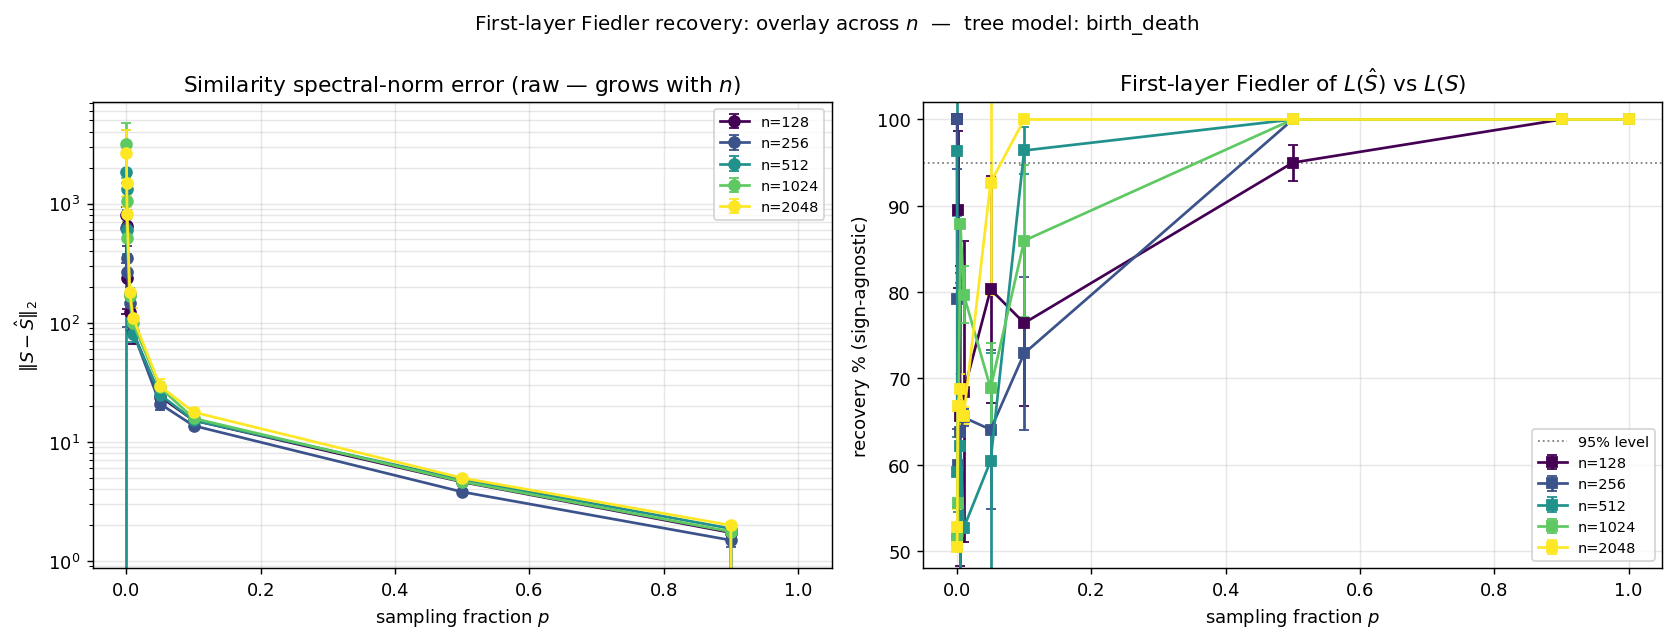


=== kingman (sweep dir: /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/20260522-105954-fiedler_sweep_kingman_L10000) ===
    n  >=95%  >=90%  >=80%
  128  0.900  0.900  0.900
  256  0.500  0.100  0.010
  512  1.000  1.000  0.900
 1024  0.500  0.500  0.500
 2048  0.900  0.500  0.500
wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/20260522-105954-fiedler_sweep_kingman_L10000/fiedler_overlay.png


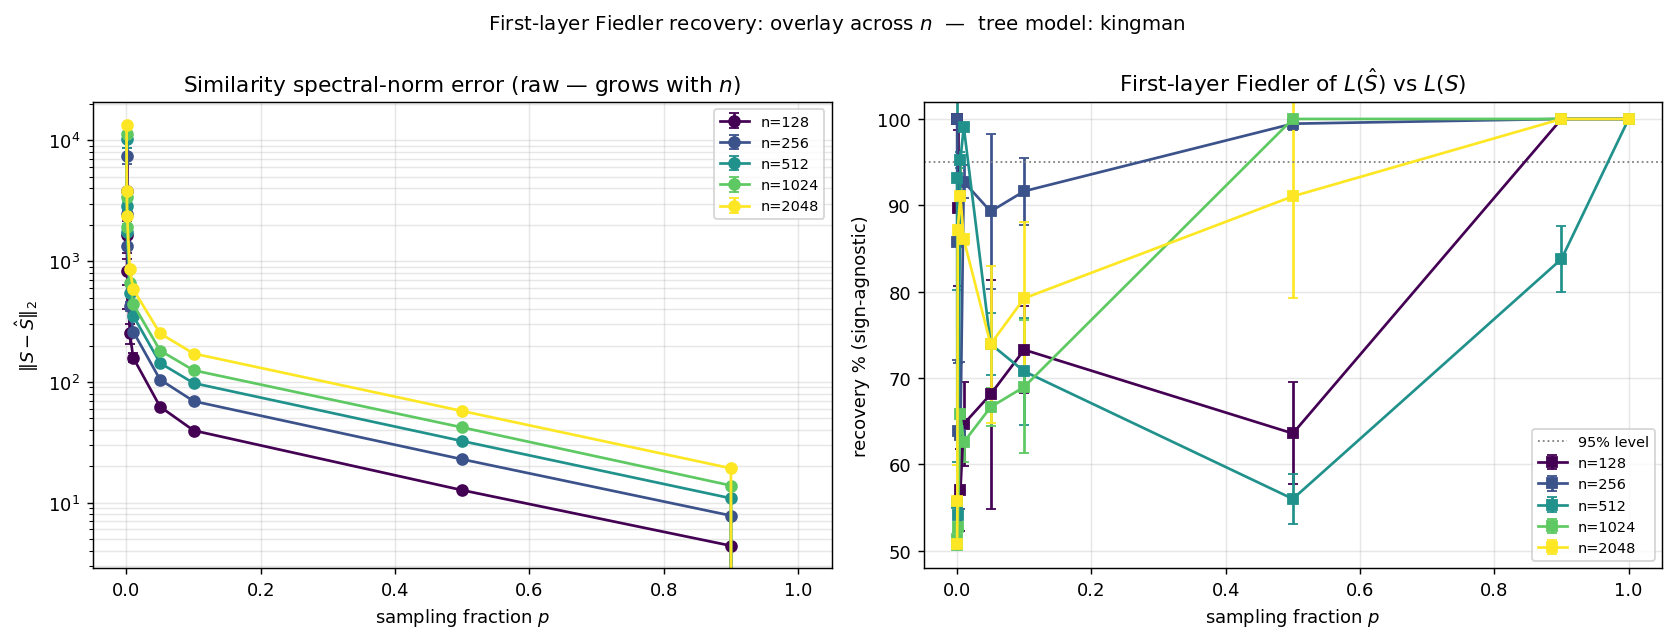

In [ ]:
for tree_model, rd in RUN_DIRS.items():
    print(f"\n=== {tree_model} (sweep dir: {rd}) ===")
    rows = _compute_p_stars(rd)
    header = f"{'n':>5}  " + '  '.join(f">={int(t*100)}%" for t in RECOVERY_THRESHOLDS)
    print(header)
    for r in rows:
        cells = [f"{r['n']:>5}"]
        for t in RECOVERY_THRESHOLDS:
            p = r['p_star_by_threshold'].get(t)
            cells.append(f"{p:>5.3f}" if (p is not None) else '  n/a')
        print('  '.join(cells))

    out_path = rd / 'fiedler_overlay.png'
    _plot_overlay(rd, out_path)
    display(Image(filename=str(out_path)))